In [1]:
# 전처리
from preprocessing_lib_Lexical_TLD_EncodingETC import prepare_X_y_groups_from_csv as prep_lex

csv_path = "phish_conca_data.csv"
df_lex,   y_lex,   g_lex,   x_lex   = prep_lex(csv_path)

In [2]:
x_lex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540196 entries, 0 to 540195
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   len_url                 540196 non-null  float64
 1   len_host                540196 non-null  float64
 2   len_path                540196 non-null  float64
 3   len_query               540196 non-null  float64
 4   cnt_dot                 540196 non-null  float64
 5   cnt_hyphen              540196 non-null  float64
 6   cnt_underscore          540196 non-null  float64
 7   cnt_at                  540196 non-null  float64
 8   cnt_percent             540196 non-null  float64
 9   cnt_slash               540196 non-null  float64
 10  cnt_qmark               540196 non-null  float64
 11  cnt_amp                 540196 non-null  float64
 12  cnt_equal               540196 non-null  float64
 13  cnt_hash                540196 non-null  float64
 14  subdomain_cnt       

In [3]:
# 학습 및 결과 확인
from CTAC_train_model_final import run_training_multi_models

results = run_training_multi_models(x_lex, y_lex, g_lex)

for r in results:
    print(r)

[LogisticRegression | 폴드 1] 선택 임계값=0.714  AP=0.6882  Acc=0.8717  P=0.7052  R=0.5589  F1=0.6236
[LogisticRegression | 폴드 2] 선택 임계값=0.683  AP=0.7087  Acc=0.8520  P=0.7001  R=0.5600  F1=0.6223
[LogisticRegression | 폴드 3] 선택 임계값=0.723  AP=0.6996  Acc=0.8550  P=0.7010  R=0.5202  F1=0.5972
[LogisticRegression | 폴드 4] 선택 임계값=0.606  AP=0.7412  Acc=0.8672  P=0.7000  R=0.7086  F1=0.7043
[LogisticRegression | 폴드 5] 선택 임계값=0.650  AP=0.7413  Acc=0.8738  P=0.7023  R=0.6415  F1=0.6705

[LogisticRegression] GroupKFold 결과 요약
thr: 0.675 ± 0.043
AP : 0.7158 ± 0.0218
Acc: 0.8639 ± 0.0089
P  : 0.7017 ± 0.0019
R  : 0.5978 ± 0.0680
F1 : 0.6436 ± 0.0385

모델 저장 완료: LogisticRegression + threshold → ./phishing_LogisticRegression.pkl

[DecisionTree | 폴드 1] 선택 임계값=0.818  AP=0.8141  Acc=0.8901  P=0.7003  R=0.7377  F1=0.7185
[DecisionTree | 폴드 2] 선택 임계값=0.684  AP=0.8380  Acc=0.8855  P=0.7088  R=0.8048  F1=0.7537
[DecisionTree | 폴드 3] 선택 임계값=0.662  AP=0.8674  Acc=0.8960  P=0.7030  R=0.8606  F1=0.7738
[DecisionTree | 

In [6]:
# 결과 데이터 프레임
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


rows = []

for model_name, model_result in results.items():
    summary = model_result["cv_summary"]

    row = {
        "model": model_name,
        "threshold_mean": summary["threshold_mean"],
        "threshold_std": summary["threshold_std"],
        "avg_precision_mean": summary["avg_precision_mean"],
        "accuracy_mean": summary["accuracy_mean"],
        "precision_mean": summary["precision_mean"],
        "recall_mean": summary["recall_mean"],
        "f1_mean": summary["f1_mean"],
    }
    rows.append(row)

df_results = pd.DataFrame(rows)
df_results

,model,threshold_mean,threshold_std,avg_precision_mean,accuracy_mean,precision_mean,recall_mean,f1_mean
0,LogisticRegression,0.6750,0.042972,0.715814,0.863942,0.701722,0.597827,0.643566
1,DecisionTree,0.6942,0.063247,0.845758,0.890971,0.705183,0.813749,0.755111
2,RandomForest,0.4036,0.099895,0.895161,0.899827,0.700988,0.900559,0.787879
3,LightGBM,0.4592,0.098969,0.913706,0.902069,0.700137,0.922798,0.795986


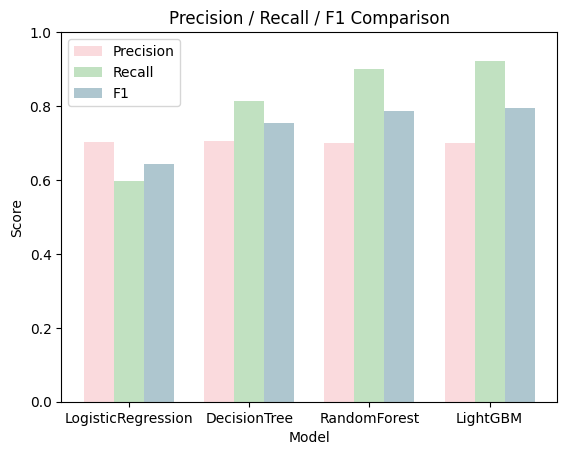

In [7]:
# 결과: 성능 비교 시각화

x = np.arange(len(df_results))
width = 0.25

x = np.arange(len(df_results))
width = 0.25

plt.figure()
plt.bar(
    x - width,
    df_results["precision_mean"],
    width,
    label="Precision",
    color="#FADADD"   # 라이트 핑크
)
plt.bar(
    x,
    df_results["recall_mean"],
    width,
    label="Recall",
    color="#C1E1C1"   # 라이트 그린
)
plt.bar(
    x + width,
    df_results["f1_mean"],
    width,
    label="F1",
    color="#AEC6CF"   # 라이트 블루그레이
)

plt.xticks(x, df_results["model"])
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 Comparison")
plt.legend()
plt.show()

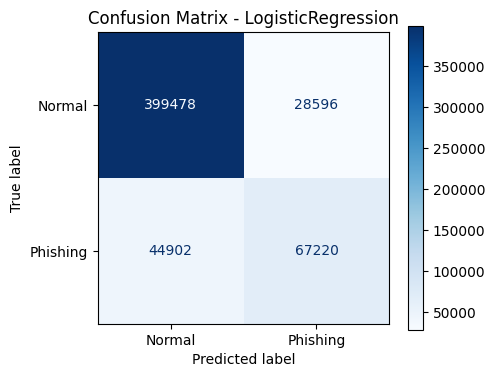

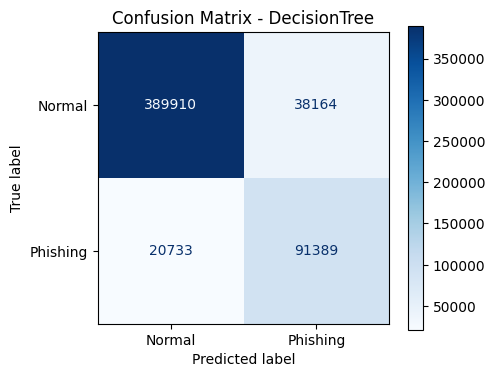

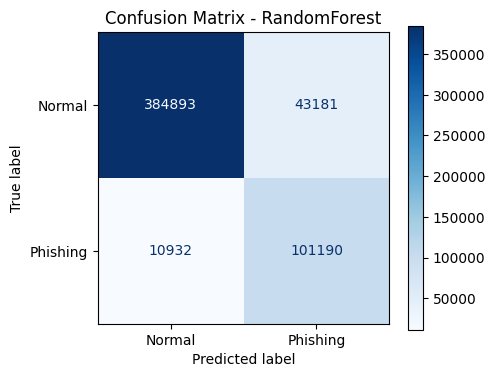

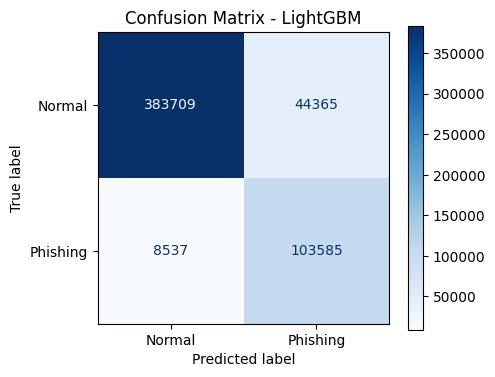

In [16]:
# 만들고 싶은 모델 4개
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model_list = ["LogisticRegression", "DecisionTree", "RandomForest", "LightGBM"]


for model_name in model_list:
    # 1) fold별 y_true / y_pred를 모두 합쳐서 "CV 전체" 혼동행렬로 만듦
    y_true_all = np.concatenate(results[model_name]["fold"]["y_test"])
    y_pred_all = np.concatenate(results[model_name]["fold"]["y_pred"])

    # 2) 혼동행렬 계산
    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])

    # 3) 시각화 (각 모델별로 따로 한 장씩)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Phishing"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix - {model_name}")

    plt.tight_layout()

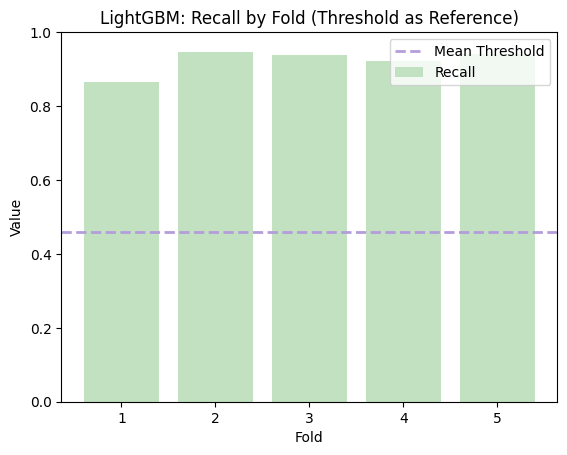

In [ ]:
# 폴드에 따른 recall 성능 비교module_project/classification_model/CTAC_train_model_final.py
lgbm_fold = results["LightGBM"]["fold"]

df_lgbm_fold = pd.DataFrame({
    "fold": range(1, len(lgbm_fold["threshold"]) + 1),
    "threshold": lgbm_fold["threshold"],
    "recall": lgbm_fold["recall"],
    "precision": lgbm_fold["precision"],
    "f1": lgbm_fold["f1"],
})

mean_thr = df_results.loc[
    df_results["model"] == "LightGBM", "threshold_mean"
].values[0]

plt.figure()
plt.bar(
    df_lgbm_fold["fold"],
    df_lgbm_fold["recall"],
    color="#C1E1C1",  # 라이트 그린
    label="Recall"
)

# threshold 평균선 (보조)
plt.axhline(
    y=mean_thr,
    color="#B39DDB",   # 라이트 퍼플
    linestyle="--",
    linewidth=2,
    label="Mean Threshold"
)

plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Value")
plt.title("LightGBM: Recall by Fold (Threshold as Reference)")
plt.legend()
plt.show()

### TF-IDF

In [10]:
from CTAC_train_model2_TFIDF_Logistic import run_training as train_tfidf
from preprocessing_lib_TFIDF import prepare_X_y_groups_from_csv as prep_tfidf

df_tfidf, y_tfidf, g_tfidf, x_tfidf = prep_tfidf(csv_path)
results_tfidf = train_tfidf(x_tfidf, y_tfidf, g_tfidf)

for r in results_tfidf:
    print("[TFIDF]", r)

[교차검증 폴드 1] 선택 임계값=0.137  평균정밀도(Average Precision)=0.9436  정확도(Accuracy)=0.9143  정밀도(Precision)=0.7003  재현율(Recall)=0.9600  F1-점수(F1-score)=0.8099
[교차검증 폴드 2] 선택 임계값=0.120  평균정밀도(Average Precision)=0.9678  정확도(Accuracy)=0.9043  정밀도(Precision)=0.7002  재현율(Recall)=0.9801  F1-점수(F1-score)=0.8169
[교차검증 폴드 3] 선택 임계값=0.146  평균정밀도(Average Precision)=0.9546  정확도(Accuracy)=0.9083  정밀도(Precision)=0.7004  재현율(Recall)=0.9718  F1-점수(F1-score)=0.8141
[교차검증 폴드 4] 선택 임계값=0.104  평균정밀도(Average Precision)=0.9492  정확도(Accuracy)=0.9027  정밀도(Precision)=0.7004  재현율(Recall)=0.9857  F1-점수(F1-score)=0.8189
[교차검증 폴드 5] 선택 임계값=0.159  평균정밀도(Average Precision)=0.9525  정확도(Accuracy)=0.9092  정밀도(Precision)=0.7001  재현율(Recall)=0.9554  F1-점수(F1-score)=0.8081

[host 기반 GroupKFold 결과 요약]
선택 임계값(평균±표준편차): 0.133 ± 0.019
평균정밀도(Average Precision): 0.9535 ± 0.0081
정확도(Accuracy)        : 0.9078 ± 0.0040
정밀도(Precision)       : 0.7003 ± 0.0001
재현율(Recall)          : 0.9706 ± 0.0115
F1-점수(F1-score)       : 0.8136 ± 0.0041

모델 저장 

In [11]:
tfidf_summary = results_tfidf["cv_summary"]
lr_row = df_results[df_results["model"] == "LogisticRegression"].iloc[0]

In [17]:
# 데이터프레임으로 저장
compare_df = pd.DataFrame([
    {
        "setting": "LR (Lexical/Numeric)",
        "accuracy": lr_row["accuracy_mean"],
        "precision": lr_row["precision_mean"],
        "recall": lr_row["recall_mean"],
        "f1": lr_row["f1_mean"],
    },
    {
        "setting": "LR (TF-IDF)",
        "accuracy": tfidf_summary["accuracy_mean"],
        "precision": tfidf_summary["precision_mean"],
        "recall": tfidf_summary["recall_mean"],
        "f1": tfidf_summary["f1_mean"],
    }
])

compare_df

,setting,accuracy,precision,recall,f1
0,LR (Lexical/Numeric),0.863942,0.701722,0.597827,0.643566
1,LR (TF-IDF),0.907758,0.700306,0.970596,0.813562


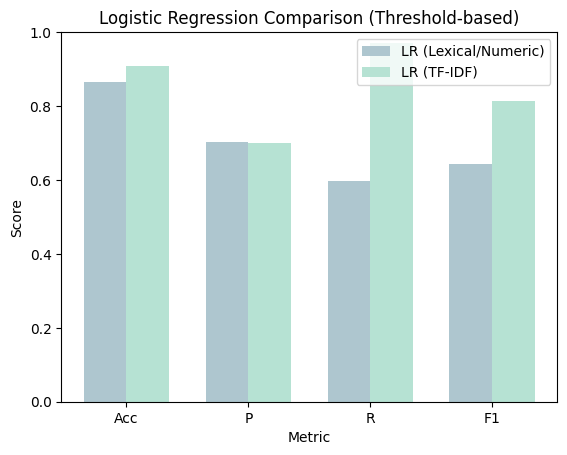

In [18]:
# 비교 시각화
metrics = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics))
width = 0.35

plt.figure()
plt.bar(x - width/2, compare_df.loc[0, metrics], width,
        label="LR (Lexical/Numeric)", color="#AEC6CF")
plt.bar(x + width/2, compare_df.loc[1, metrics], width,
        label="LR (TF-IDF)", color="#B6E2D3")

plt.xticks(x, ["Acc", "P", "R", "F1"])
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Logistic Regression Comparison (Threshold-based)")
plt.legend()
plt.show()